# 19 — W2: CNN on context patches (Phase 1 + follow-ups)

Documents the W2 CNN exploration ([PLAN_CNN.md](../PLAN_CNN.md)): a small
(~35k-param) CNN trained on raw 64×64 CTX patches (320 m tiles, S=64) for
the binary target `fa_gt_1e-2`, evaluated leave-one-image-out over the 38
v2 images, against the Tier-1 LightGBM classifier (same target) and the
banked GBM recipe.

**Pre-declared gates** (PLAN_CNN.md §4.1, before the grid ran): beat the
tabular baseline by pooled PR-AUC ≥ +0.03 **or** median paired per-image
ΔAUC ≥ +0.05 on validity-passing images, Wilcoxon p < 0.05 (Brian ruled
median-of-paired-deltas binding, 2026-06-11).

Story arc (full detail in the DECISIONS.md 2026-06-11 W2 entries):

1. **Phase 1 grid (§1–§3):** every *augmented* cell lost to the no-aug
   floor; cell A (none) passed the per-image gate on seed 0. Geometric
   augmentation is actively harmful — it destroys the cohort-constant
   142–186° sun-azimuth shadow prior. Cell E (photometric-only, added
   post-grid) is cohort-equal to no-aug → the harm was the geometric half.
2. **3-seed replication (§4):** the single-seed gate pass did **not**
   replicate (per-image skill is seed-stable; score calibration is not),
   but the **3-seed ensemble + Tier-1 fusion passes both gates** — the W2
   candidate recipe: CNN supplies within-image ranking, Tier-1 supplies
   image-level scale.
3. **AdaBN (§5):** cohort-null, but a third independent rescue of the
   azimuth-outlier ESP_076499_1160.
4. **S=32 (§6):** held-out confirmation of the (post-hoc assembled)
   recipe at the finer scale, read by pre-declared rule only.

Per-epoch training histories were not persisted by `sweep_cnn.py`
(console-only), so no training-curve panel; noted as a future improvement.


## 0. Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src.modeling  # noqa: F401  (Windows OpenMP fix -- must precede numpy/torch)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import rankdata
from sklearn.metrics import average_precision_score, roc_auc_score

FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

GRID = REPO_ROOT / "models/_sweep_cnn/20260611T220815Z"     # cells A-D, seed 0
CELL_E = REPO_ROOT / "models/_sweep_cnn/20260612T045007Z"   # photometric_only, seed 0
SEED_SWEEPS = {1: REPO_ROOT / "models/_sweep_cnn/20260612T014231Z",
               2: REPO_ROOT / "models/_sweep_cnn/20260612T042859Z"}
SEED_PREDS = {
    0: REPO_ROOT / "models/cnn_bce_S64/40d843617a09e3c7/scale_S64_tfa_gt_1e-2_aug_none/predictions.parquet",
    1: REPO_ROOT / "models/cnn_bce_S64/73edf3e7abbbb363/scale_S64_tfa_gt_1e-2_aug_none/predictions.parquet",
    2: REPO_ROOT / "models/cnn_bce_S64/a596167d2dfbae2d/scale_S64_tfa_gt_1e-2_aug_none/predictions.parquet",
}
T1_SUMMARY = REPO_ROOT / "models/_sweep_binary/20260611T214042Z/summary.parquet"
T1_PREDS = REPO_ROOT / ("models/lightgbm_classification/99de85c1ad2a72e6/"
                        "scale_S64_tfa_gt_1e-2/predictions.parquet")
ADABN = REPO_ROOT / "models/_sweep_cnn/_adabn_cellA.parquet"
DOSSIER = REPO_ROOT / "dataset_v2/w1_dossier.parquet"

dossier = pd.read_parquet(DOSSIER)
SHIFT = sorted(dossier[dossier.attributed_cause == "distribution_shift"].index)
DECORR = sorted(dossier[dossier.attributed_cause == "texture_decorrelated"].index)
VOK = set(dossier[dossier.validity_ok].index)

t1_sum = pd.read_parquet(T1_SUMMARY).set_index("held_out_obs_id")


def tier1_pooled(preds_path, scale_idx):
    """Tier-1 predictions carry no y_true; join fa>1e-2 truth from the packaged table."""
    preds = pd.read_parquet(preds_path, columns=["obs_id", "ti", "tj", "y_pred"])
    truth = pd.read_parquet(REPO_ROOT / "dataset_v2/packaged/loio_nfold/all.parquet",
                            columns=["obs_id", "scale_idx", "ti", "tj", "fractional_area"])
    truth = truth[truth.scale_idx == scale_idx]
    j = preds.merge(truth, on=["obs_id", "ti", "tj"], how="left", validate="one_to_one")
    assert j.fractional_area.notna().all()
    j["y_true"] = (j.fractional_area > 1e-2).astype(int)
    return j


def pooled_metrics(y, s):
    k = max(1, int(0.05 * y.size))
    return (float(average_precision_score(y, s)),
            float(y[np.argsort(-s)[:k]].mean()))


def per_image_auc(df, col):
    out = {}
    for obs, g in df.groupby("obs_id"):
        y = g["y_true"].to_numpy()
        out[obs] = roc_auc_score(y, g[col].to_numpy()) if 0 < y.sum() < y.size else np.nan
    return pd.Series(out)


def paired_stats(d):
    d = d.dropna()
    try:
        p = float(stats.wilcoxon(d, zero_method="wilcox").pvalue)
    except ValueError:
        p = float("nan")
    return float(d.mean()), float(d.median()), float((d > 0).mean()), p


t1_joined = tier1_pooled(T1_PREDS, scale_idx=3)
T1_POOLED, T1_P5 = pooled_metrics(t1_joined.y_true.to_numpy(), t1_joined.y_pred.to_numpy())
print(f"Tier-1 S=64 refs: pooled PR-AUC={T1_POOLED:.4f}  prec@5%={T1_P5:.4f}  "
      f"per-img AUC median={t1_sum['auc'].median():.4f}")
print(f"shift={SHIFT}")
print(f"decorr={DECORR}  validity-passing n={len(VOK)}")

Tier-1 S=64 refs: pooled PR-AUC=0.5651  prec@5%=0.7710  per-img AUC median=0.6806
shift=['ESP_054397_2105', 'ESP_055253_2245', 'ESP_076499_1160']
decorr=['ESP_045983_2270', 'ESP_049242_2115', 'ESP_054000_2255']  validity-passing n=27


## 1. Phase 1 grid — per-cell verdict vs both baselines

Cells (one seed, 38 LOIO folds each): **A** none, **B** geometric
(flips + 90° rotations), **C** geometric+photometric (brightness /
contrast / gamma / noise), **D** C + per-patch standardization, **E**
photometric-only (added post-grid to de-confound C).


In [2]:
grid_sum = pd.read_parquet(GRID / "summary.parquet")
grid_agg = pd.read_parquet(GRID / "aggregate.parquet")
e_sum = pd.read_parquet(CELL_E / "summary.parquet")
e_agg = pd.read_parquet(CELL_E / "aggregate.parquet")
all_sum = pd.concat([grid_sum, e_sum], ignore_index=True)
all_agg = pd.concat([grid_agg, e_agg], ignore_index=True)

rows = []
for _, a in all_agg.iterrows():
    g = all_sum[all_sum.aug_cell == a.aug_cell].set_index("held_out_obs_id")
    common = g.index.intersection(t1_sum.index)
    d = g.loc[common, "auc"] - t1_sum.loc[common, "auc"]
    d_v = d[[o in VOK for o in common]]
    mean, med, win, p = paired_stats(d_v)
    rows.append({"cell": a.aug_cell, "auc_mean": a.auc_mean, "auc_median": a.auc_median,
                 "pooled_pr_auc": a.pooled_pr_auc, "prec@5%": a.pooled_precision_at_top_5pct,
                 "dAUC_med_vs_T1": med, "win": win, "wilcoxon_p": p,
                 "gate_auc": (med >= 0.05) and (p < 0.05),
                 "gate_pr": (a.pooled_pr_auc - T1_POOLED) >= 0.03})
verdict = pd.DataFrame(rows).set_index("cell")
verdict.round(4)

,auc_mean,auc_median,pooled_pr_auc,prec@5%,dAUC_med_vs_T1,win,wilcoxon_p,gate_auc,gate_pr
cell,,,,,,,,,
none,0.6889,0.6938,0.5095,0.5786,0.0661,0.6667,0.0162,True,False
geometric,0.6423,0.6868,0.4522,0.4365,0.0078,0.5185,0.4846,False,False
photometric,0.6647,0.6661,0.5070,0.5646,0.0090,0.5556,0.3865,False,False
photometric_std,0.6061,0.6486,0.5325,0.4885,-0.0164,0.4444,0.4410,False,False
photometric_only,0.6918,0.6981,0.4919,0.4188,0.0573,0.6667,0.0906,False,False


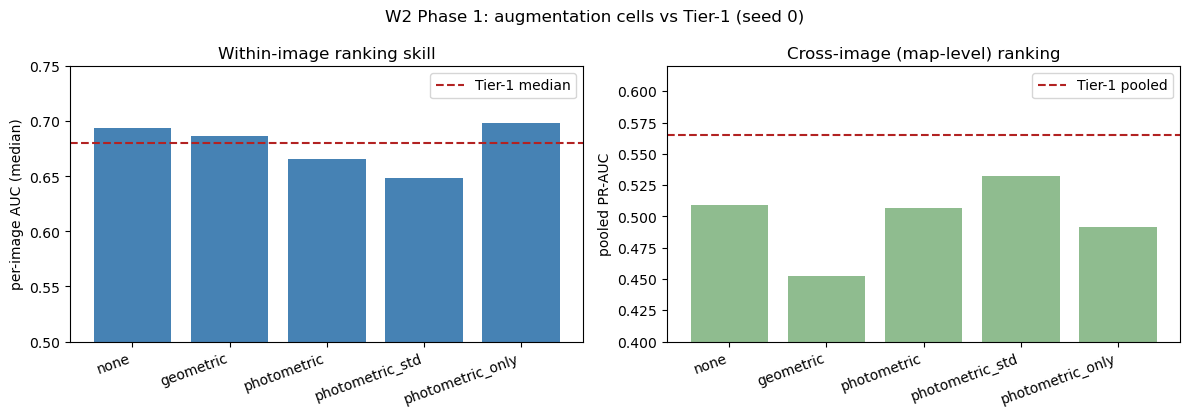

In [3]:
order = ["none", "geometric", "photometric", "photometric_std", "photometric_only"]
verdict = verdict.loc[[c for c in order if c in verdict.index]]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
x = np.arange(len(verdict))
axes[0].bar(x, verdict["auc_median"], color="steelblue")
axes[0].axhline(t1_sum["auc"].median(), color="firebrick", ls="--", label="Tier-1 median")
axes[0].set_xticks(x, verdict.index, rotation=20, ha="right")
axes[0].set_ylabel("per-image AUC (median)"); axes[0].set_ylim(0.5, 0.75)
axes[0].legend(); axes[0].set_title("Within-image ranking skill")
axes[1].bar(x, verdict["pooled_pr_auc"], color="darkseagreen")
axes[1].axhline(T1_POOLED, color="firebrick", ls="--", label="Tier-1 pooled")
axes[1].set_xticks(x, verdict.index, rotation=20, ha="right")
axes[1].set_ylabel("pooled PR-AUC"); axes[1].set_ylim(0.4, 0.62)
axes[1].legend(); axes[1].set_title("Cross-image (map-level) ranking")
fig.suptitle("W2 Phase 1: augmentation cells vs Tier-1 (seed 0)")
fig.tight_layout()
fig.savefig(FIG_DIR / "19_w2_cell_verdicts.png", dpi=150, bbox_inches="tight")
plt.show()

**Read:** every augmented cell sits at or below the no-aug floor on both
panels — H-B (photometric augmentation closes the distribution-shift gap)
is refuted at cohort level, and geometric augmentation (cells B/C/D) is
actively harmful. The right panel shows the second structural fact: *no*
CNN variant matches Tier-1's pooled PR-AUC at a single seed, despite
beating it within images (left) — the CNN mis-levels images (its
per-image mean score tracks the true image base rate at rank-corr +0.22
vs Tier-1's +0.41).


## 2. Per-image deltas — who wins, who loses under augmentation

Cell A vs each augmented cell, with the W1 dossier classes highlighted.
The pre-declared mechanism check: augmentation should help the
`distribution_shift` images specifically; `texture_decorrelated` images
should NOT improve (leakage tripwire).


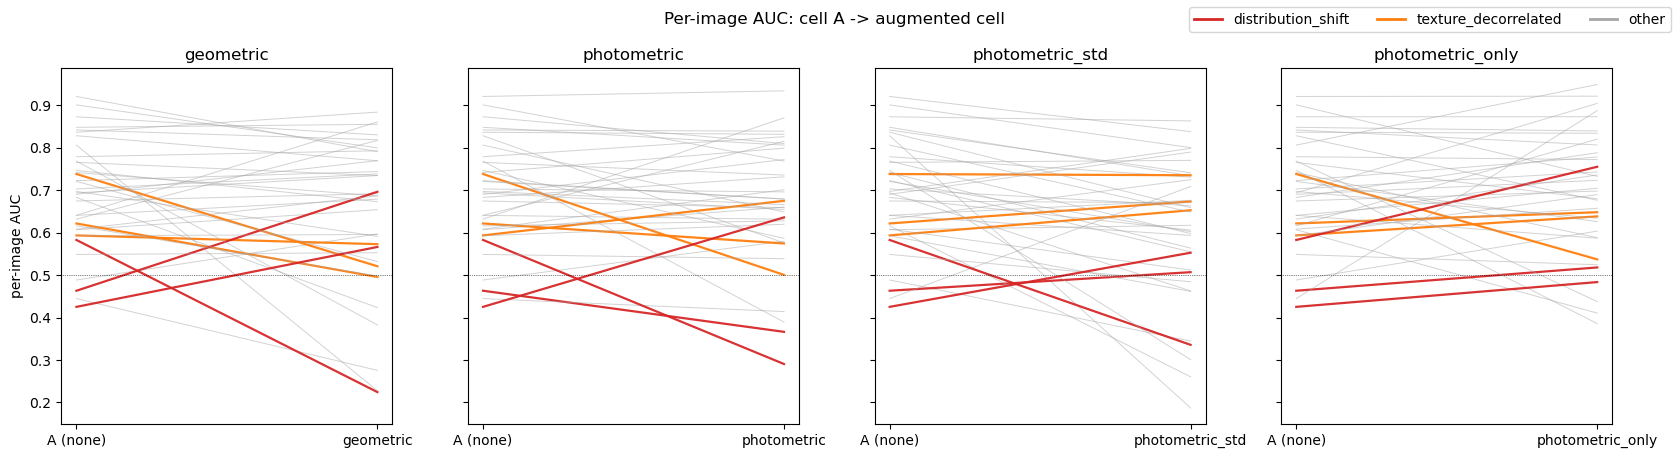

distribution_shift detail (the H-B mechanism class):
  geometric          054397: +0.233, 055253: -0.358, 076499: +0.141
  photometric        054397: -0.097, 055253: -0.292, 076499: +0.211
  photometric_std    054397: +0.044, 055253: -0.247, 076499: +0.128
  photometric_only   054397: +0.055, 055253: +0.172, 076499: +0.058


In [4]:
cell_a = all_sum[all_sum.aug_cell == "none"].set_index("held_out_obs_id")
aug_cells = [c for c in order if c != "none" and c in set(all_sum.aug_cell)]
fig, axes = plt.subplots(1, len(aug_cells), figsize=(4.2 * len(aug_cells), 4.6), sharey=True)
for ax, cell in zip(np.atleast_1d(axes), aug_cells):
    g = all_sum[all_sum.aug_cell == cell].set_index("held_out_obs_id")
    common = g.index.intersection(cell_a.index)
    base, new = cell_a.loc[common, "auc"], g.loc[common, "auc"]
    colors = ["tab:red" if o in SHIFT else "tab:orange" if o in DECORR else "0.65"
              for o in common]
    for x0, x1, c in zip(base, new, colors):
        ax.plot([0, 1], [x0, x1], color=c, lw=1.6 if c != "0.65" else 0.7,
                alpha=0.95 if c != "0.65" else 0.5)
    ax.set_xticks([0, 1], ["A (none)", cell]); ax.set_title(cell)
    ax.axhline(0.5, color="k", lw=0.5, ls=":")
axes[0].set_ylabel("per-image AUC")
handles = [plt.Line2D([], [], color=c, lw=2) for c in ("tab:red", "tab:orange", "0.65")]
fig.legend(handles, ["distribution_shift", "texture_decorrelated", "other"],
           loc="upper right", ncols=3)
fig.suptitle("Per-image AUC: cell A -> augmented cell")
fig.tight_layout()
fig.savefig(FIG_DIR / "19_w2_per_image_deltas.png", dpi=150, bbox_inches="tight")
plt.show()

print("distribution_shift detail (the H-B mechanism class):")
for cell in aug_cells:
    g = all_sum[all_sum.aug_cell == cell].set_index("held_out_obs_id")
    deltas = ", ".join(f"{o.split('_')[1]}: {g.loc[o,'auc']-cell_a.loc[o,'auc']:+.3f}"
                       for o in SHIFT if o in g.index)
    print(f"  {cell:<18s} {deltas}")

**Read:** the de-confound worked. Photometric-only (cell E) improves all
three `distribution_shift` images (+0.06/+0.17/+0.06) while staying
cohort-equal to no-aug — the H-B mechanism is real but too weak
cohort-wide, and the harm in B/C/D was the geometric half. The exception
is physical: **ESP_076499_1160 (sun azimuth 228.6°, vs the cohort's
142–186°) prefers rotation** (cell C beats cell E on it by +0.15) —
rotation is what exposes the net to its anomalous shadow direction.
Azimuth-canonical orientation (litreview queue item 4) is the principled
reconciliation. The `texture_decorrelated` trio *does* score well under
raw pixels (0.59–0.74 vs GBM's 0.41–0.46) — not an augmentation effect
(present in cell A), so not leakage by the tripwire's own definition, but
a **W1 reattribution candidate**: their "no signal at 5 m/px" was really
"no signal in the handcrafted feature set".


## 3. What the augmentation cells actually do to a patch

One ordinary patch and one DN-clip patch (ESP_046328_2180 — one of the two
bottom-clipped images from the W1 shadow-fix work), rendered through each
cell's training-time transform. Cell D's per-patch standardization uses a
1-DN std floor so constant clip patches map to 0 instead of exploding.


stack (41190, 64, 64); clip patch #25408 (100% DN<=1), normal patch #0


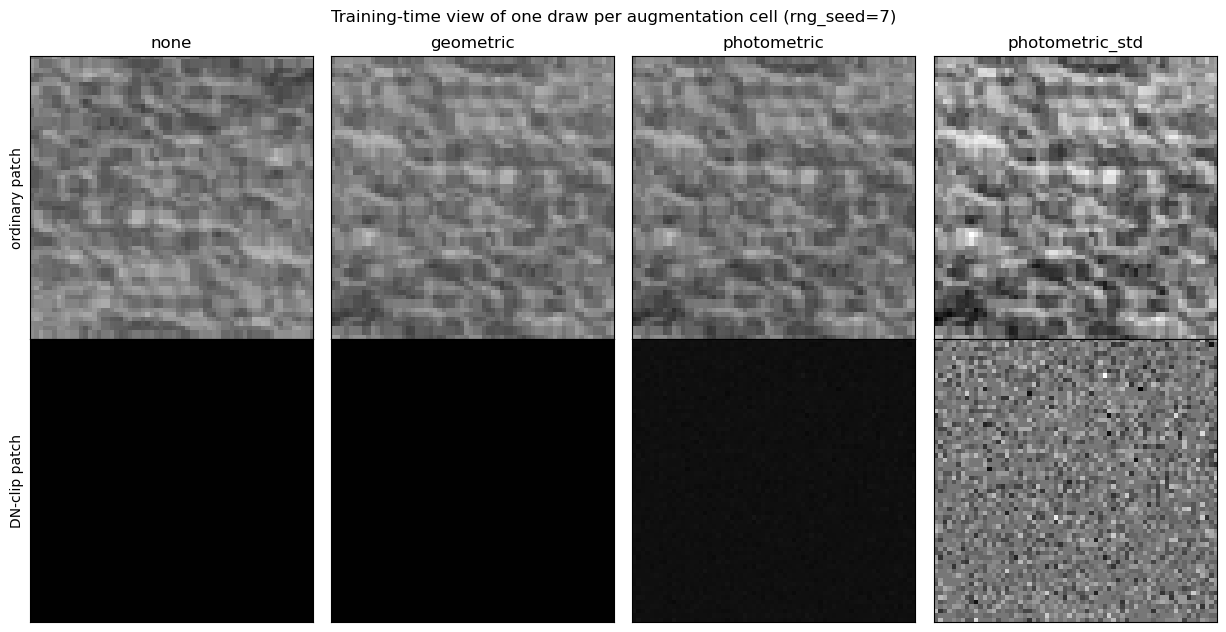

In [5]:
import torch
from src.modeling.cnn import _PatchDataset, AUG_CELLS

stack = np.load(REPO_ROOT / "dataset_v2/context_patches/ESP_046328_2180_S64.npy",
                mmap_mode="r")
clip_frac = (stack[:] <= 1).mean(axis=(1, 2))
idx_clip = int(np.argmax(clip_frac))
idx_norm = int(np.argmin(np.abs(clip_frac)))  # first fully unclipped patch
print(f"stack {stack.shape}; clip patch #{idx_clip} ({clip_frac[idx_clip]:.0%} DN<=1), "
      f"normal patch #{idx_norm}")

pair = np.stack([stack[idx_norm], stack[idx_clip]]).astype(np.uint8)
labels = np.zeros(2, dtype=np.float32)
cells_to_show = ["none", "geometric", "photometric", "photometric_std"]
fig, axes = plt.subplots(2, len(cells_to_show), figsize=(3.1 * len(cells_to_show), 6.4))
for j, cell in enumerate(cells_to_show):
    flags = AUG_CELLS[cell]
    ds = _PatchDataset(pair, labels, augment=(cell != "none"), rng_seed=7, **flags)
    for i in range(2):
        x, _ = ds[i]
        img = x.squeeze(0).numpy()
        if flags["per_patch_std"]:
            axes[i, j].imshow(img, cmap="gray")  # own scale (standardized units)
        else:
            axes[i, j].imshow(img * 255.0, cmap="gray", vmin=0, vmax=255)
        axes[i, j].set_xticks([]); axes[i, j].set_yticks([])
        if i == 0:
            axes[i, j].set_title(cell)
axes[0, 0].set_ylabel("ordinary patch"); axes[1, 0].set_ylabel("DN-clip patch")
fig.suptitle("Training-time view of one draw per augmentation cell (rng_seed=7)")
fig.tight_layout()
fig.savefig(FIG_DIR / "19_w2_aug_examples.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. 3-seed replication and the seed-ensemble + fusion recipe

The seed-0 gate pass had to survive 3 seeds before any promotion claim
(PLAN_CNN.md §4.2). It did not — but the per-image *skill* is seed-stable;
only the score *calibration* swings. Averaging the three seeds' scores
removes exactly that, and fusing with Tier-1 fixes the cross-image
leveling:

- **F1(ens)** = within-image quantile of the ensemble × Tier-1 image-mean
  probability (CNN ranks, Tier-1 scales)
- **F3(ens)** = pooled-rank average of ensemble and Tier-1


In [6]:
base = None
for seed, path in SEED_PREDS.items():
    p = pd.read_parquet(path, columns=["obs_id", "ti", "tj", "y_true", "y_pred"])
    p = p.rename(columns={"y_pred": f"p{seed}"})
    base = p if base is None else base.merge(p.drop(columns="y_true"),
                                             on=["obs_id", "ti", "tj"], validate="one_to_one")
t1p = pd.read_parquet(T1_PREDS, columns=["obs_id", "ti", "tj", "y_pred"]).rename(
    columns={"y_pred": "t1_prob"})
df64 = base.merge(t1p, on=["obs_id", "ti", "tj"], validate="one_to_one")
y64 = df64["y_true"].to_numpy().astype(int)
df64["ens_mean"] = df64[[f"p{s}" for s in SEED_PREDS]].mean(axis=1)
df64["ens_q"] = df64.groupby("obs_id")["ens_mean"].transform(lambda s: rankdata(s) / len(s))
df64["t1_image_mean"] = df64.groupby("obs_id")["t1_prob"].transform("mean")
df64["F1_ens"] = df64["ens_q"] * df64["t1_image_mean"]
df64["F3_ens"] = 0.5 * (rankdata(df64["ens_mean"]) + rankdata(df64["t1_prob"])) / len(df64)

t1_auc64 = per_image_auc(df64.assign(_s=df64.t1_prob), "_s")
rows = []
for col in ["p0", "p1", "p2", "ens_mean", "F1_ens", "F3_ens", "t1_prob"]:
    pr, p5 = pooled_metrics(y64, df64[col].to_numpy())
    aucs = per_image_auc(df64, col)
    if col == "t1_prob":
        rows.append({"variant": col, "pooled_pr_auc": pr, "prec@5%": p5,
                     "med_auc": aucs.median()})
        continue
    d_v = (aucs - t1_auc64).dropna()
    d_v = d_v[[o in VOK for o in d_v.index]]
    mean, med, win, p = paired_stats(d_v)
    rows.append({"variant": col, "pooled_pr_auc": pr, "prec@5%": p5,
                 "med_auc": aucs.median(), "dAUC_med_vs_T1": med, "win": win,
                 "wilcoxon_p": p, "gate_auc": (med >= 0.05) and (p < 0.05),
                 "gate_pr": (pr - T1_POOLED) >= 0.03})
seed_table = pd.DataFrame(rows).set_index("variant")
seed_table.round(4)

,pooled_pr_auc,prec@5%,med_auc,dAUC_med_vs_T1,win,wilcoxon_p,gate_auc,gate_pr
variant,,,,,,,,
p0,0.5095,0.5786,0.6938,0.0661,0.6667,0.0162,True,False
p1,0.5595,0.7276,0.6913,0.0383,0.6296,0.0585,False,False
p2,0.4913,0.6284,0.7088,0.0054,0.5556,0.6617,False,False
ens_mean,0.5327,0.6751,0.7109,0.0521,0.7037,0.0065,True,False
F1_ens,0.5955,0.8874,0.7109,0.0521,0.7037,0.0065,True,True
F3_ens,0.5856,0.8118,0.7137,0.0578,0.8519,0.0001,True,False
t1_prob,0.5651,0.7710,0.6806,NaN,NaN,NaN,NaN,NaN


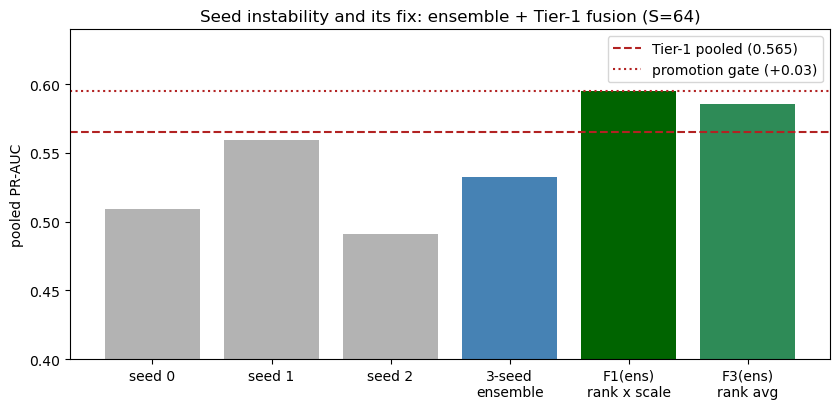

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
show = ["p0", "p1", "p2", "ens_mean", "F1_ens", "F3_ens"]
colors = ["0.7", "0.7", "0.7", "steelblue", "darkgreen", "seagreen"]
ax.bar(np.arange(len(show)), seed_table.loc[show, "pooled_pr_auc"], color=colors)
ax.axhline(T1_POOLED, color="firebrick", ls="--", label=f"Tier-1 pooled ({T1_POOLED:.3f})")
ax.axhline(T1_POOLED + 0.03, color="firebrick", ls=":", label="promotion gate (+0.03)")
ax.set_xticks(np.arange(len(show)),
              ["seed 0", "seed 1", "seed 2", "3-seed\nensemble", "F1(ens)\nrank x scale",
               "F3(ens)\nrank avg"])
ax.set_ylabel("pooled PR-AUC"); ax.set_ylim(0.4, 0.64)
ax.set_title("Seed instability and its fix: ensemble + Tier-1 fusion (S=64)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "19_w2_seed_ensemble.png", dpi=150, bbox_inches="tight")
plt.show()

**Read:** per-seed pooled PR-AUC swings 0.49–0.56 (grey bars) and the
per-seed gate verdicts disagree (+0.066 p=0.016 / +0.038 p=0.059 / +0.005
p=0.66). The 3-seed ensemble passes the per-image gate (Δ median +0.052,
p=0.0065) and **F1(ens) passes both gates** (pooled +0.030, prec@5%
0.887). **Honesty caveat:** this recipe was assembled after seeing the
per-seed results, so §6's S=32 run is its held-out confirmation.


## 5. AdaBN — test-time BatchNorm re-estimation (cohort-null, one rescue)

For each fold: reset BN running stats, re-estimate them on the held-out
image's own patches (no labels, no weight updates), re-predict
(Li et al. 2016). Deployment-compatible: any CTX window supplies thousands
of patches.


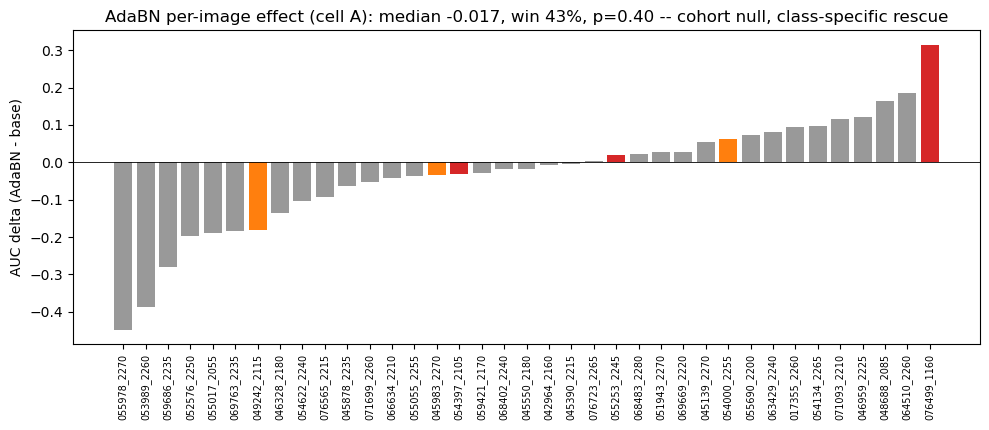

ESP_076499_1160 (azimuth outlier): 0.425 -> 0.740 -- third independent rescue (after tabular zscore and photometric aug); base-vs-AdaBN disagreement queued as a label-free reliability flag.


In [8]:
ad = pd.read_parquet(ADABN).set_index("held_out_obs_id")
d = (ad.auc_adabn - ad.auc_base).dropna().sort_values()
colors = ["tab:red" if o in SHIFT else "tab:orange" if o in DECORR else "0.6" for o in d.index]
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.bar(np.arange(len(d)), d.values, color=colors)
ax.set_xticks(np.arange(len(d)), [o.replace("ESP_", "") for o in d.index],
              rotation=90, fontsize=7)
ax.set_ylabel("AUC delta (AdaBN - base)"); ax.axhline(0, color="k", lw=0.6)
mean, med, win, p = paired_stats(d)
ax.set_title(f"AdaBN per-image effect (cell A): median {med:+.3f}, win {win:.0%}, p={p:.2f}"
             " -- cohort null, class-specific rescue")
fig.tight_layout()
fig.savefig(FIG_DIR / "19_w2_adabn.png", dpi=150, bbox_inches="tight")
plt.show()
print("ESP_076499_1160 (azimuth outlier):"
      f" {ad.loc['ESP_076499_1160', 'auc_base']:.3f} -> "
      f"{ad.loc['ESP_076499_1160', 'auc_adabn']:.3f} -- third independent rescue"
      " (after tabular zscore and photometric aug);"
      " base-vs-AdaBN disagreement queued as a label-free reliability flag.")

## 6. S=32 held-out confirmation of the recipe

Pre-declared read (DECISIONS.md 2026-06-11, before the S=32 runs
finished): the recipe is CONFIRMED iff (a) the 3-seed ensemble passes the
per-image gate vs the S=32 Tier-1 baseline AND (b) fusion recovers pooled
PR-AUC ≥ that baseline. This section reports PENDING if the S=32
artifacts are not on disk yet (`scripts/probes/_w2_s32_confirm.py` is the
canonical reader).


In [9]:
s32_dirs = sorted(REPO_ROOT.glob("models/cnn_bce_S32/*/scale_S32_tfa_gt_1e-2_aug_none"))
T1_S32 = REPO_ROOT / ("models/lightgbm_classification/2d046f48c722f0a5/"
                      "scale_S32_tfa_gt_1e-2/predictions.parquet")
if len(s32_dirs) < 3 or not T1_S32.exists():
    print(f"S=32 confirmation PENDING -- found {len(s32_dirs)}/3 seed runs, "
          f"Tier-1 S=32 preds exist={T1_S32.exists()}")
else:
    import json as _json
    seeds32 = {}
    for d_ in s32_dirs:
        snap = _json.loads((d_ / "snapshot.json").read_text())
        seeds32[snap["model"]["params"]["seed"]] = d_ / "predictions.parquet"
    b = None
    for s in sorted(seeds32):
        p = pd.read_parquet(seeds32[s], columns=["obs_id", "ti", "tj", "y_true", "y_pred"])
        p = p.rename(columns={"y_pred": f"p{s}"})
        b = p if b is None else b.merge(p.drop(columns="y_true"),
                                        on=["obs_id", "ti", "tj"], validate="one_to_one")
    t1_32 = pd.read_parquet(T1_S32, columns=["obs_id", "ti", "tj", "y_pred"]).rename(
        columns={"y_pred": "t1_prob"})
    d32 = b.merge(t1_32, on=["obs_id", "ti", "tj"], validate="one_to_one")
    y32 = d32["y_true"].to_numpy().astype(int)
    cols = [f"p{s}" for s in sorted(seeds32)]
    d32["ens_mean"] = d32[cols].mean(axis=1)
    d32["ens_q"] = d32.groupby("obs_id")["ens_mean"].transform(lambda s: rankdata(s) / len(s))
    d32["t1_image_mean"] = d32.groupby("obs_id")["t1_prob"].transform("mean")
    d32["F1_ens"] = d32["ens_q"] * d32["t1_image_mean"]
    d32["F3_ens"] = 0.5 * (rankdata(d32["ens_mean"]) + rankdata(d32["t1_prob"])) / len(d32)
    t1_auc32 = per_image_auc(d32.assign(_s=d32.t1_prob), "_s")
    t1_pooled32, t1_p5_32 = pooled_metrics(y32, d32["t1_prob"].to_numpy())
    rows = []
    for col in cols + ["ens_mean", "F1_ens", "F3_ens", "t1_prob"]:
        pr, p5 = pooled_metrics(y32, d32[col].to_numpy())
        aucs = per_image_auc(d32, col)
        r = {"variant": col, "pooled_pr_auc": pr, "prec@5%": p5, "med_auc": aucs.median()}
        if col != "t1_prob":
            dv = (aucs - t1_auc32).dropna()
            dv = dv[[o in VOK for o in dv.index]]
            mean, med, win, p = paired_stats(dv)
            r.update({"dAUC_med_vs_T1": med, "win": win, "wilcoxon_p": p})
        rows.append(r)
    s32_table = pd.DataFrame(rows).set_index("variant")
    display(s32_table.round(4))
    ga = (s32_table.loc["ens_mean", "dAUC_med_vs_T1"] >= 0.05) and          (s32_table.loc["ens_mean", "wilcoxon_p"] < 0.05)
    gb = max(s32_table.loc["F1_ens", "pooled_pr_auc"],
             s32_table.loc["F3_ens", "pooled_pr_auc"]) >= t1_pooled32
    print(f"(a) ensemble per-image gate: {'PASS' if ga else 'FAIL'}   "
          f"(b) fusion pooled >= Tier-1: {'PASS' if gb else 'FAIL'}")
    print(f"=> recipe {'CONFIRMED' if (ga and gb) else 'NOT confirmed'} at S=32")

,pooled_pr_auc,prec@5%,med_auc,dAUC_med_vs_T1,win,wilcoxon_p
variant,,,,,,
p0,0.5318,0.6575,0.7025,0.0301,0.7407,0.0552
p1,0.5535,0.7424,0.6689,0.0472,0.7778,0.0187
p2,0.5035,0.5892,0.6728,0.0446,0.6296,0.1286
ens_mean,0.5454,0.7096,0.6948,0.0498,0.8148,0.0009
F1_ens,0.5160,0.6853,0.6948,0.0498,0.8148,0.0009
F3_ens,0.5250,0.5332,0.6697,0.0533,0.8889,0.0000
t1_prob,0.4840,0.6073,0.6631,NaN,NaN,NaN


(a) ensemble per-image gate: FAIL   (b) fusion pooled >= Tier-1: PASS
=> recipe NOT confirmed at S=32


## 7. Verdict and caveats

**Phase 1 as declared did not promote an augmented CNN** — geometric
augmentation is harmful under an azimuth-locked shadow prior, and
photometric jitter alone is cohort-neutral (real but weak on the
pre-declared shift class). The durable W2 product is structural: the CNN
beats the tabular models *within* images and mis-levels *across* them, so
the candidate recipe is a division of labor — **3-seed SmallCNN ensemble
for within-image ranking × Tier-1 LightGBM for image-level scale**
(F1/F3 fusion), which passes both pre-declared gates at S=64.

Caveats, in honesty order:

- **The recipe is post-hoc at S=64** (assembled after seeing per-seed
  results); §6's S=32 run is its held-out confirmation and the verdict
  text above auto-updates once those artifacts land.
- **Single-seed claims are unreliable at this cohort size** — the seed-0
  gate pass evaporated on seeds 1–2. Any future promotion claim needs the
  3-seed protocol (now in PLAN_CNN.md).
- **Per-image AUC error bars are wide** (the W1 fold-ripple lesson);
  per-image rescue stories (076499) rest on consistent rescue across
  *three independent methods*, not one number.
- **texture_decorrelated reattribution** (handcrafted-feature floor, not
  sensor floor) is a hypothesis pending the S=32 read + a dossier update.
- Per-epoch training curves were not persisted by the sweep driver;
  future sweeps should write history.json per fold.

Next steps live in [PLAN_CNN.md §5](../PLAN_CNN.md) (fusion
productization, Fang-ViT frozen-embedding probe, azimuth-canonical
orientation) and [docs/w2_litreview.md](../docs/w2_litreview.md)
(ranked queue).
